In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import util
from skimage.io import imread
from skimage.filters import  threshold_triangle, median, sobel, gaussian
from skimage.measure import label,  regionprops_table, regionprops,  moments_central
from skimage.morphology import  disk, remove_small_objects, binary_dilation, remove_small_holes , erosion, closing
from skimage.transform import rotate
from scipy.ndimage import rotate, binary_dilation
from skimage.transform import probabilistic_hough_line
from skimage.draw import line
from skimage.filters import gaussian, threshold_yen, threshold_triangle
from skimage import util
from liffile import LifFile
import napari
import warnings
warnings.filterwarnings("ignore")

In [3]:
folder = Path(r"Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6")
lif_files = list(folder.glob("*.lif"))
print(len(lif_files))


2


In [ ]:
# for lif_path in lif_files:
#     lif_name = "".join(os.path.basename(lif_path).lower().replace(".lif", "")).replace(".", "_")
#     print(lif_name)
#     with LifFile(lif_path) as lif:
#         number_of_lifs = len(lif.images)
#         print(number_of_lifs)
        
#         # for i in range(number_of_lifs):
#         #     output = segment_and_quantify(i,lif, lif_path, classifier_path)
#         #     all_outputs.append(output)
#         # totals = pd.concat(all_outputs)
#         # totals.to_csv("{}.csv".format(lif_name))
#         test = lif_files[0]

day5_exp6


In [27]:
lif_path = lif_files[1]
image_index = 0

dextran_channel = 2
with LifFile(lif_path) as lif:
    img = lif.images[0]
    print("shape:", img.shape)


    # Often available:
    print("dims:", getattr(img, "dims", None))
    print("n_frames:", getattr(img, "n_frames", None))
    print("n_channels:", getattr(img, "n_channels", None))
    print("n_z", getattr(img, "n_z", None))
    print(f"Opened image {image_index}, {lif_files[image_index]}")
    img = img.asarray()


shape: (4, 3, 41, 512, 512)
dims: ('T', 'C', 'Z', 'Y', 'X')
n_frames: None
n_channels: None
n_z None
Opened image 0, Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6\Day5_Exp6.lif


In [28]:
dextran_t0 = img[0, 2, :, :, :]
print("dextran_t0 shape:", dextran_t0.shape)


dextran_t0 shape: (41, 512, 512)


In [29]:
viewer = napari.Viewer()
viewer.add_image(dextran_t0, name="dextran_t0")

<Image layer 'dextran_t0' at 0x2840d0bc6d0>

In [38]:
example_z = 20


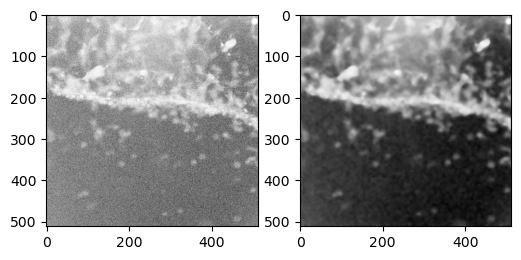

In [42]:
slice = util.invert(dextran_t0[example_z, :, :])
median_filtered = median(slice, disk(5))
fig, ax = plt.subplots(ncols = 2, figsize=(6,3))
ax[0].imshow(slice, cmap='gray')
ax[1].imshow(median_filtered, cmap='gray')

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


(<Figure size 800x500 with 8 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Isodata'}>,
        <Axes: title={'center': 'Li'}>, <Axes: title={'center': 'Mean'}>,
        <Axes: title={'center': 'Minimum'}>,
        <Axes: title={'center': 'Otsu'}>,
        <Axes: title={'center': 'Triangle'}>,
        <Axes: title={'center': 'Yen'}>], dtype=object))

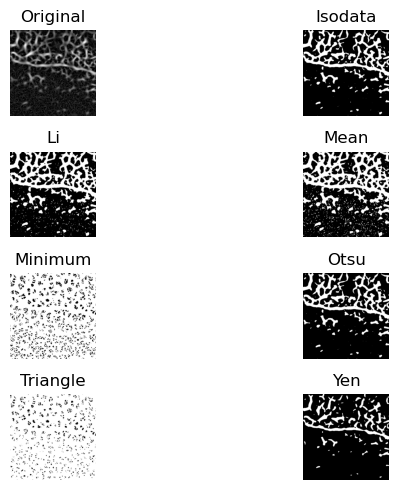

In [64]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color, exposure
from skimage.filters import gaussian, threshold_otsu, threshold_sauvola
from skimage.filters import frangi, sato
from skimage.morphology import remove_small_objects, remove_small_holes, skeletonize, binary_closing, disk
from skimage.measure import label, regionprops


# 1) gentle denoise + contrast
img_s = gaussian(slice, sigma=1.5)
img_s = exposure.equalize_adapthist(img_s, clip_limit=0.01)

# 2) ridge enhancement (try sato OR frangi)
ridge = sato(img_s, sigmas=np.linspace(2,8,10), black_ridges=False)
#ridge = frangi(img_s, sigmas=np.linspace(1, 4, 7), black_ridges=False)

ridge = exposure.rescale_intensity(ridge)
try_all_threshold(ridge)

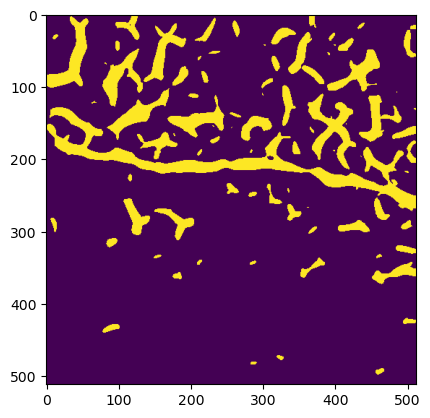

In [65]:

# 3) threshold (global Otsu often works; Sauvola if illumination varies)
try:
    thr = threshold_yen(ridge)
    bw = ridge > thr
except ValueError:
    thr = threshold_sauvola(ridge, window_size=51, k=0.2)
    bw = ridge > thr
plt.imshow(bw)

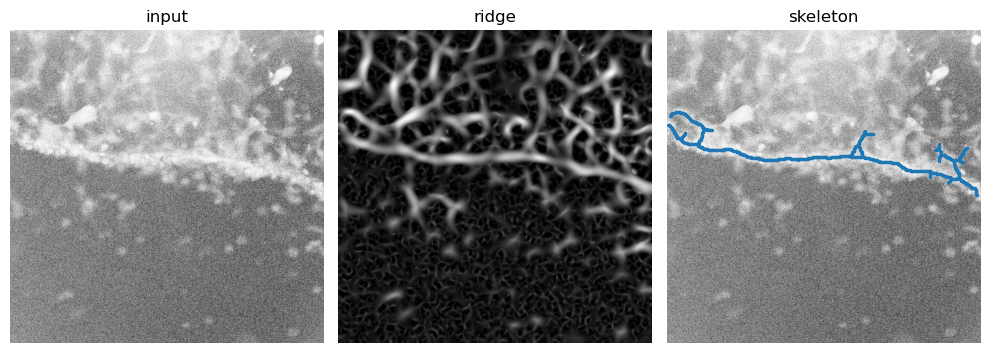

In [66]:

# 4) cleanup
bw = binary_closing(bw, footprint=disk(2))
bw = remove_small_objects(bw, min_size=600)
# bw = remove_small_holes(bw, area_threshold=200)

# 5) skeletonize to get a 1-pixel line
skel = skeletonize(bw)

# 6) keep the main curve (largest skeleton component)
lab = label(skel)
if lab.max() > 0:
    props = regionprops(lab)
    biggest = max(props, key=lambda p: p.area)
    skel_main = (lab == biggest.label)
else:
    skel_main = skel

# Visual check
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.title("input"); plt.imshow(slice, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("ridge"); plt.imshow(ridge, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("skeleton"); plt.imshow(slice, cmap="gray"); 
ys, xs = np.nonzero(skel_main)
plt.scatter(xs, ys, s=2)
plt.axis("off")
plt.tight_layout()
plt.show()

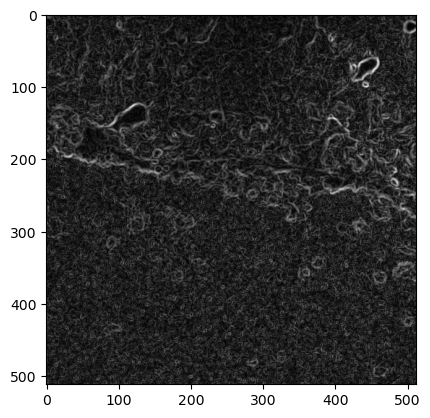

In [36]:
plt.imshow(sobel(gaussian(slice)), cmap='gray')